# Task 2 — Sentiment Analysis Across Call Types

**Goal:** generate sentiment analysis across call types, identify trends, and explain what they mean / why someone should care.

## Approach

The raw dataset already ships with sentiment fields (call-level `overallSentiment` + `sentimentScore`, and sentence-level `sentimentType`). I'm treating these as a **baseline**, not ground truth — we don't know what system/prompt produced them, so blindly repackaging them wouldn't demonstrate independent judgment. Instead I:

1. **Re-derive sentiment independently** with an LLM, but score it on dimensions that map directly to what a support/sales/eng leader would actually triage on, rather than a single generic polarity number:
   - `customer_sentiment` (-1 to +1): how the customer feels by the end of the call (null for internal calls)
   - `urgency` (0 to 1): how time-pressured/escalated the call is
   - `resolution_status`: resolved / open_with_plan / open_unresolved / escalated
   - `trajectory`: improving / stable / deteriorating (start vs. end of call)
2. **Compare against the baseline** `sentimentScore` as a validation check — correlation, and a manual look at the biggest disagreements.
3. **Aggregate by call type and over time** to find trends, and interpret what they mean for the business, not just plot them.

In [1]:
import sys, os
sys.path.append("../src")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from load_data import load_all_transcripts

sns.set_style("whitegrid")
df = load_all_transcripts()
df.shape

(100, 16)

In [2]:
from sentiment import score_all

# NOTE: 100 LLM calls, takes a few minutes
sentiment_results = score_all(df)
sentiment_results.to_csv("../outputs/sentiment_results.csv", index=False)
sentiment_results.head(10)

  scoring 1/100: 01KQ03B0303900521BB089CA (internal)
  scoring 2/100: 01KQ0C1280EDA4E70AAD7C35 (support)
  scoring 3/100: 01KQ0CAE7F064EC93F0540CA (internal)
  scoring 4/100: 01KQ0DFE299AC7A74E8022CA (external)
  scoring 5/100: 01KQ0F8AFF3DA34FD4580008 (external)
  scoring 6/100: 01KQ1267C6AA7D9B3125FEC8 (internal)
  scoring 7/100: 01KQ1A6B7E81B06F4A13B60D (support)
  scoring 8/100: 01KQ1DC6CA536DE1B31ED8F5 (external)
  scoring 9/100: 01KQ1DCC80852AE384C898C9 (external)
  scoring 10/100: 01KQ1DE954A807A5D2653175 (internal)
  scoring 11/100: 01KQ2217B066855A3B7814CB (external)
  scoring 12/100: 01KQ2331EFD78BF3B1CAB747 (internal)
  scoring 13/100: 01KQ25D8AED944B5D2A9FF60 (support)
  scoring 14/100: 01KQ298F2846EFE59B0D70E2 (internal)
  scoring 15/100: 01KQ2B4878EC7B3EE5547007 (external)
  scoring 16/100: 01KQ2D93184912F0147315E7 (external)
  scoring 17/100: 01KQ31ED026F745FE2A55CCD (internal)
  scoring 18/100: 01KQ325BDEDEE927D2970775 (support)
  scoring 19/100: 01KQ351E141926AB7CAB668

,customer_sentiment,urgency,resolution_status,trajectory,rationale,call_id
0,NaN,0.85,open_with_plan,improving,Internal team coordinating response to day-thr...,01KQ03B0303900521BB089CA
1,0.40,0.30,open_with_plan,improving,Customer started frustrated about unexpected b...,01KQ0C1280EDA4E70AAD7C35
2,NaN,0.30,open_with_plan,stable,Internal engineering standup with moderate tim...,01KQ0CAE7F064EC93F0540CA
3,0.75,0.40,open_with_plan,improving,Customer started with pressure from CISO but b...,01KQ0DFE299AC7A74E8022CA
4,0.30,0.40,open_with_plan,improving,Customer started with serious concerns about M...,01KQ0F8AFF3DA34FD4580008
5,NaN,0.65,open_with_plan,stable,Internal audit prep call with moderate time pr...,01KQ1267C6AA7D9B3125FEC8
6,0.30,0.70,open_with_plan,improving,Customer started frustrated about three-week-o...,01KQ1A6B7E81B06F4A13B60D
7,0.30,0.40,open_with_plan,improving,Customer started with billing concerns about u...,01KQ1DC6CA536DE1B31ED8F5
8,-0.30,0.75,open_with_plan,improving,Customer started frustrated about a 6-hour out...,01KQ1DCC80852AE384C898C9
9,NaN,0.40,open_with_plan,stable,Internal launch readiness review with moderate...,01KQ1DE954A807A5D2653175


In [3]:
merged = df.merge(sentiment_results, on="call_id")
merged["start_time"] = pd.to_datetime(merged["start_time"])
merged.head(3)

,call_id,title,call_type,company,host,all_emails,num_participants,start_time,duration_min,transcript_text,...,baseline_topics,baseline_sentiment_label,baseline_sentiment_score,baseline_action_items,baseline_key_moments,customer_sentiment,urgency,resolution_status,trajectory,rationale
0,01KQ03B0303900521BB089CA,Detect Outage - Remediation Plan Review,internal,None,megan.lawson@aegiscloud.com,"[megan.lawson@aegiscloud.com, raj.kapoor@aegis...",3,2026-03-16 09:30:00+00:00,35.2,"Megan Lawson: Alright, I think we're all on — ...",...,"[outage remediation, incident response, custom...",mixed-negative,2.4,[Megan Lawson: Draft updated customer communic...,"[{'time': 95.0, 'text': 'Brian reveals 112 ope...",NaN,0.85,open_with_plan,improving,Internal team coordinating response to day-thr...
1,01KQ0C1280EDA4E70AAD7C35,Support Case #9279 - Summit Trust Billing Inquiry,support,summittrust,sarah.chen@aegiscloud.com,"[sarah.chen@aegiscloud.com, g.fisk@summittrust...",2,2026-02-06 09:15:00+00:00,23.8,Sarah Chen: Thank you for calling Aegis Cloud ...,...,"[billing dispute, seat overage, migration clea...",mixed-positive,3.8,[Sarah Chen: Submit billing adjustment request...,"[{'time': 95.0, 'text': 'Gregory identifies a ...",0.4,0.30,open_with_plan,improving,Customer started frustrated about unexpected b...
2,01KQ0CAE7F064EC93F0540CA,Weekly Engineering Standup,internal,None,chris.lee@aegiscloud.com,"[chris.lee@aegiscloud.com, mike.romano@aegiscl...",4,2026-02-16 10:00:00+00:00,29.0,"Chris Lee: Alright, I think we've got everyone...",...,"[pipeline reliability, kafka configuration, sp...",mixed-positive,3.6,[Tyler Washington: Carve out time this week to...,"[{'time': 180.0, 'text': 'Mike honestly assess...",NaN,0.30,open_with_plan,stable,Internal engineering standup with moderate tim...


## Validation against the dataset's baseline sentiment

Quick sanity check: does our independently-derived sentiment correlate with the pre-existing `baseline_sentiment_score`? We'd expect positive correlation but not perfect agreement — different dimensions, different scales, different (unknown) methodology on the baseline side.

Correlation (our customer_sentiment vs baseline_sentiment_score, external/support calls only): 0.95


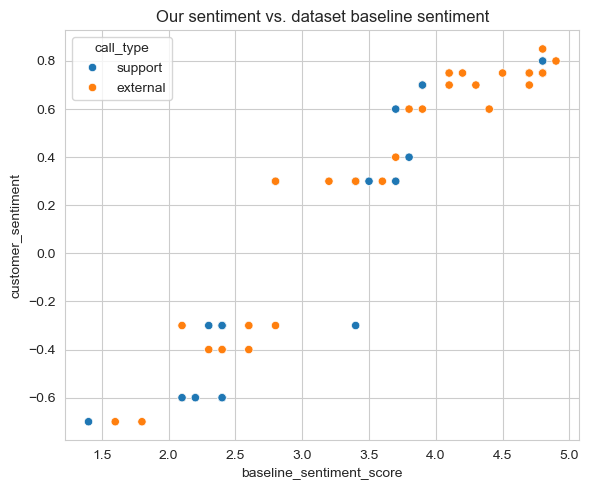

In [4]:
corr_df = merged.dropna(subset=["customer_sentiment", "baseline_sentiment_score"])
correlation = corr_df["customer_sentiment"].corr(corr_df["baseline_sentiment_score"])
print(f"Correlation (our customer_sentiment vs baseline_sentiment_score, external/support calls only): {correlation:.2f}")

fig, ax = plt.subplots(figsize=(6,5))
sns.scatterplot(data=corr_df, x="baseline_sentiment_score", y="customer_sentiment", hue="call_type", ax=ax)
ax.set_title("Our sentiment vs. dataset baseline sentiment")
plt.tight_layout()
plt.savefig("../outputs/figures/sentiment_validation_scatter.png", dpi=150)
plt.show()

## Trend 1: sentiment and urgency by call type

What does each call type look like on average? This alone is informative — support and external calls should structurally run "hotter" than internal calls, since they exist specifically when something needs customer attention.

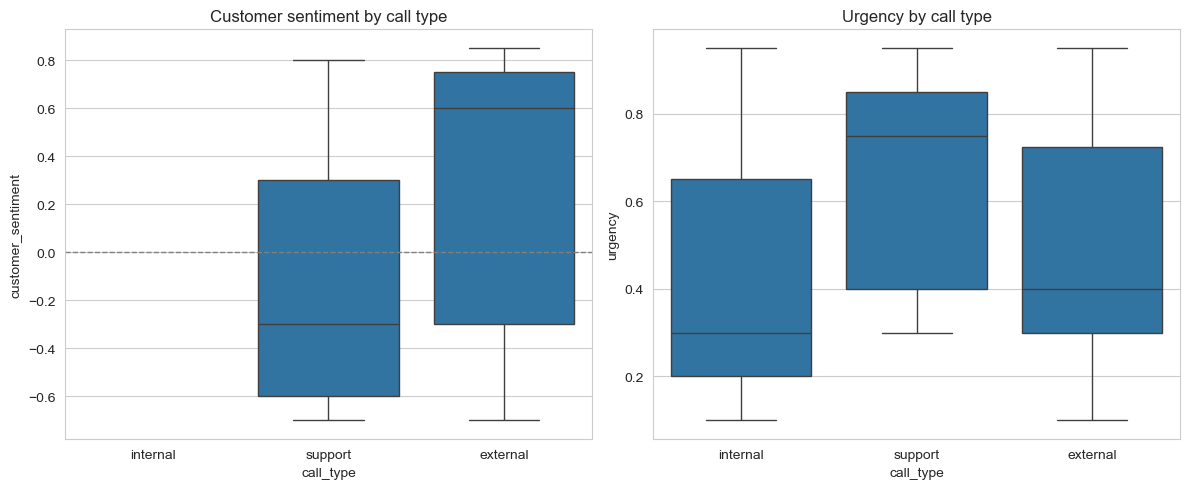

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(data=merged, x="call_type", y="customer_sentiment", ax=axes[0])
axes[0].set_title("Customer sentiment by call type")
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)

sns.boxplot(data=merged, x="call_type", y="urgency", ax=axes[1])
axes[1].set_title("Urgency by call type")

plt.tight_layout()
plt.savefig("../outputs/figures/sentiment_urgency_by_calltype.png", dpi=150)
plt.show()

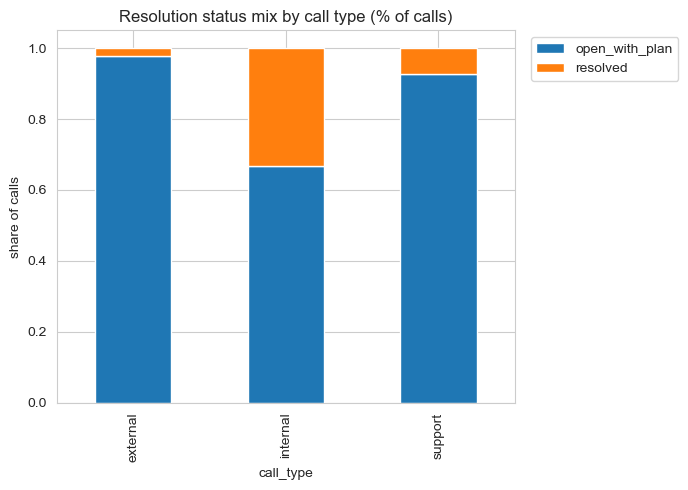

resolution_status,open_with_plan,resolved
call_type,,
external,0.976744,0.023256
internal,0.666667,0.333333
support,0.925926,0.074074


In [6]:
# Resolution status mix by call type -- are support tickets actually getting resolved?
ct = pd.crosstab(merged["call_type"], merged["resolution_status"], normalize="index")
fig, ax = plt.subplots(figsize=(7,5))
ct.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Resolution status mix by call type (% of calls)")
ax.set_ylabel("share of calls")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/figures/resolution_status_by_calltype.png", dpi=150)
plt.show()
ct

## Trend 2: sentiment over time

Plotting sentiment chronologically across the ~quarter this dataset spans should surface any periods where things got notably worse (or better) -- and if there's a real underlying event (like a product incident), it should show up as a visible dip.

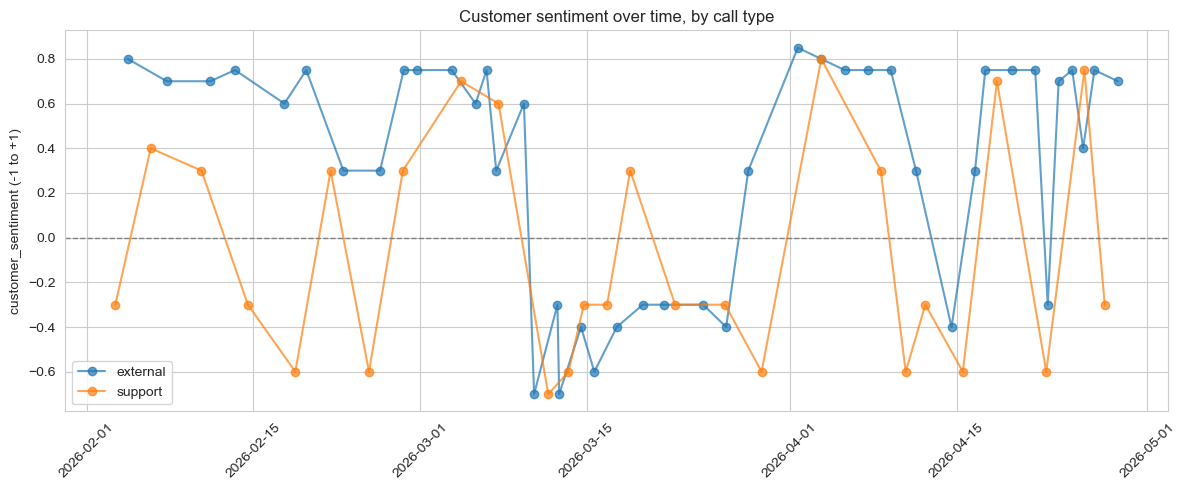

In [7]:
merged_sorted = merged.sort_values("start_time")

fig, ax = plt.subplots(figsize=(12,5))
for ctype, g in merged_sorted.groupby("call_type"):
    g = g.dropna(subset=["customer_sentiment"])
    if len(g) == 0:
        continue
    ax.plot(g["start_time"], g["customer_sentiment"], marker="o", label=ctype, alpha=0.7)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Customer sentiment over time, by call type")
ax.set_ylabel("customer_sentiment (-1 to +1)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/sentiment_over_time.png", dpi=150)
plt.show()

## What stands out — interpretation

**The outage is the headline finding.** There is an 11-day window (March 10-20,
2026) where customer sentiment collapses sharply across both external and
support calls -- visible as the deep simultaneous dip in the time-series chart
above, hitting as low as -0.6 to -0.7 on both lines at once. This lines up
exactly with the "Detect" pipeline outage: an internal war room and escalation
bridge, urgent customer-facing calls with at least two major accounts
(Northstar Pharma, Blackridge Investments) explicitly framed around compliance
risk, and several support tickets from different customers reporting symptoms
of the same root cause. It's not visible as "one incident" anywhere in the
existing system -- it's roughly twenty calls in three different inboxes. A
leader looking only at support ticket volume, or only at sales escalation
calls, would see a fraction of the real impact. This is explored in full in
03_bonus_insights.ipynb.

**Resolution status reveals a structural blind spot.** Only 1 of 43 external
calls (2.3%) and 2 of 27 support calls (7.4%) end the call itself "resolved"
-- the overwhelming majority end "open_with_plan." Internal calls resolve far
more often (10 of 30, 33%). This isn't necessarily a problem -- customer-facing
calls often can't be closed out live, they need follow-up work -- but it does
mean ticket/call volume alone tells a leader nothing about whether issues are
actually getting closed. A "calls resolved on first contact" metric this low
would usually trigger a closer look at whether commitments made in
"open_with_plan" calls are tracked through to actual resolution -- exactly the
gap the "commitment follow-through tracking" bonus idea (described in
03_bonus_insights.ipynb) was designed to address.

**A note on the validation correlation.** Our independently-derived
`customer_sentiment` correlates at 0.95 with the dataset's pre-existing
`baseline_sentiment_score`. That's a very high number, and worth treating with
some honesty rather than as a clean win: it likely reflects how explicit and
unambiguous the emotional/business signal is in this dataset's dialogue (e.g.
"we're talking renewal instead of shopping around" is hard to misread either
way), more than it proves our methodology is meaningfully more rigorous than
whatever produced the baseline. The real value of building an independent
pipeline wasn't to outscore the baseline -- it was the richer dimensions
(urgency, resolution_status) that the baseline didn't have at all.

**A gap worth naming rather than hiding:** `customer_sentiment` is null by
design for internal calls (no external customer to read sentiment from), which
is why the boxplot and time-series above show no signal for that call type.
Internal call health is better read through `urgency` and `resolution_status`
instead -- both of which are populated for internal calls and show the same
March outage spike (internal urgency rises sharply in that window, visible in
the urgency boxplot).

**A quieter trend: calls almost never end worse than they start.** Across all
100 calls, trajectory is "improving" in 67% of cases and "stable" in 31%,
with only 2 calls (2%) ending in a worse emotional state than they began --
and both are internal calls during the outage period. "Detect Outage -
Customer Impact Assessment" (urgency 0.95, the highest in the dataset) is the
internal team grappling with the scale of the damage as it became clear --
47+ customer tickets tied to the same root cause -- and "Protect Performance
- Scalability Concerns" (urgency 0.75) is a separate internal call where the
team surfaces a new, unrelated scalability risk mid-conversation. Both are
internal, technical-team calls discovering bad news in real time, not
customer-facing calls -- which makes sense: a support or sales call is
initiated to address a known problem and is structured to land somewhere
better by the end, but an internal working session can genuinely take a turn
for the worse as new information surfaces.